In [1]:
# Notebook to run the stage 1 and stage 2 estimation on cross-sectional data, encompassing the whole SP500 stocks

In [22]:
import pandas as pd
import numpy as np
import random 
from grid_search import estimate_single_config

from joblib import Parallel, delayed
from tqdm.auto import tqdm

random.seed(42)

In [3]:
#import the wide dataframe
df = pd.read_csv('../../data/X.csv', index_col=0)

#import the features dataframe
feature_matrix = pd.read_csv("../../data/merged_return_topic_data.csv", index_col=0, parse_dates=True)

In [4]:
#remove columns that are not just numbers in the name
df = df[[col for col in df.columns if col.replace('.','',1).isdigit()]]

In [5]:
# transform the df data into log returns from normal returns
df = np.log(1 + df)

#convert index to datetime
df.index = pd.to_datetime(df.index)

In [6]:
# tryng to run the estimation on one stock first
y = df['10145']
X = feature_matrix.copy()

#change all the ' ' in the column names to '_'
X.columns = [col.replace(' ', '_') for col in X.columns]

# Separate topic (name) and stock (numeric) columns
topic_cols = [col for col in X.columns if not str(col).isdigit()]
stock_cols = [col for col in X.columns if str(col).isdigit()]

# User-selected number of each (or use len(...) for "all")
num_topics = len(topic_cols)  # e.g., 100
num_stocks = 0

# Randomly sample (without replacement), limited by available count
selected_topics = random.sample(topic_cols, min(num_topics, len(topic_cols)))
selected_stocks = random.sample(stock_cols, min(num_stocks, len(stock_cols)))

# Final filtered dataframe
X = X[selected_topics + selected_stocks]

# Convert stock returns to log returns: log(1+r)
X[selected_stocks] = np.log(X[selected_stocks] + 1)

#convert y index to datetime
#y.index = pd.to_datetime(y.index)
# ensure that all indices align

common_index = X.index.intersection(y.index)
X = X.loc[common_index]
y = y.loc[common_index]

In [7]:
#define the paramters for the esitmation
window_size = 195
n_lags = 5
lambda_val = 0.0029

In [8]:
results = estimate_single_config(X, y, window_size, n_lags, lambda_val)
results

{'summary': {'window_size': 195,
  'n_lags': 5,
  'lambda': 0.0029,
  'r2_insample_stage1': np.float64(0.03339853767658844),
  'r2_oos_stage1': np.float64(-0.01224387597822818),
  'r2_insample_stage2': np.float64(0.001247230029387869),
  'r2_oos_stage2': np.float64(-0.0003802906759748925),
  'kappa': np.float64(0.20542427366458144),
  'kappa_tstat': np.float64(1.8258348152011936),
  'intercept': np.float64(0.0007147304303442468),
  'intercept_tstat': np.float64(2.2691063612576663),
  'n_observations': 1687,
  'n_windows': 1689,
  'n_oos_predictions_stage2': nan},
 'details':            date  window_size  n_lags  lambda  window_index  lasso_intercept  \
 0    2010-10-18          195       5  0.0029             0              0.0   
 1    2010-10-19          195       5  0.0029             1              0.0   
 2    2010-10-20          195       5  0.0029             2              0.0   
 3    2010-10-21          195       5  0.0029             3              0.0   
 4    2010-10-22   

In [13]:
results['details'].shape

(1, 9)

In [9]:
#compute the average number of selected features
avg_num_selected_features = results['details']['num_nonzero_coefficients'].mean()

#now create a row with the number of times each feature is selected


In [10]:
#main function: for each column we run the estimation and then save the results only if statistically significant
#initialize an empty dataframe to store the results, set the index as the stock tickers
results_df = pd.DataFrame(columns=['avg_num_selected_features'], index=df.columns)
# add columns for each feature indicating how many times it was selected
new_cols = pd.DataFrame(
    0,
    index=results_df.index,
    columns=[
        f"Lasso_{feature}_lag_{lag}"
        for feature in X.columns
        for lag in range(1, n_lags + 1)
    ]
)

results_df = pd.concat([results_df, new_cols], axis=1)



In [24]:
def _process_one_stock_joblib(stock, df, X, window_size, n_lags, lambda_val):
    y = df[stock]
    common_index = X.index.intersection(y.index)
    X_stock = X.loc[common_index]
    y_stock = y.loc[common_index]

    results = estimate_single_config(X_stock, y_stock, window_size, n_lags, lambda_val)
    details = results.get("details", None)
    if details is None or details.shape[0] < 2:
        return stock, None

    row = {}
    row["avg_num_selected_features"] = details["num_nonzero_coefficients"].mean()

    for feature in X.columns:
        for lag_number in range(1, n_lags + 1):
            col_name = f"Lasso_{feature}_lag_{lag_number}"
            if col_name in details.columns:
                row[col_name] = (details[col_name] != 0).sum()
            else:
                row[col_name] = 0

    return stock, row


def run_parallel_estimations(df, X, results_df, window_size, n_lags, lambda_val, n_jobs=-1, batch_size=10):
    stocks = list(df.columns)

    out = Parallel(n_jobs=n_jobs, backend="loky", batch_size=batch_size)(
        delayed(_process_one_stock_joblib)(stock, df, X, window_size, n_lags, lambda_val)
        for stock in tqdm(stocks, desc="Estimating per stock")
    )

    # One write per stock to avoid fragmentation
    for stock, row in out:
        if row is None:
            continue
        for k, v in row.items():
            results_df.at[stock, k] = v

    return results_df


In [ ]:
results_df = run_parallel_estimations(df, X, results_df, window_size, n_lags, lambda_val)

Estimating per stock:   0%|          | 0/1620 [00:00<?, ?it/s]

In [15]:
results_df.head()

,avg_num_selected_features,Lasso_Buffett_lag_1,Lasso_Buffett_lag_2,Lasso_Buffett_lag_3,Lasso_Buffett_lag_4,Lasso_Buffett_lag_5,Lasso_Music_industry_lag_1,Lasso_Music_industry_lag_2,Lasso_Music_industry_lag_3,Lasso_Music_industry_lag_4,...,Lasso_European_sovereign_debt_lag_1,Lasso_European_sovereign_debt_lag_2,Lasso_European_sovereign_debt_lag_3,Lasso_European_sovereign_debt_lag_4,Lasso_European_sovereign_debt_lag_5,Lasso_Negotiations_lag_1,Lasso_Negotiations_lag_2,Lasso_Negotiations_lag_3,Lasso_Negotiations_lag_4,Lasso_Negotiations_lag_5
10065,0.478698,2,10,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
10145,4.357988,2,25,2,2,2,2,2,2,2,...,2,5,2,2,2,6,2,2,10,2
10294,29.512426,11,136,66,2,33,11,60,189,2,...,99,332,31,104,110,36,26,86,32,5
10375,16.092899,2,2,2,4,104,2,2,93,2,...,2,74,2,13,43,2,2,61,50,2
10516,NaN,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


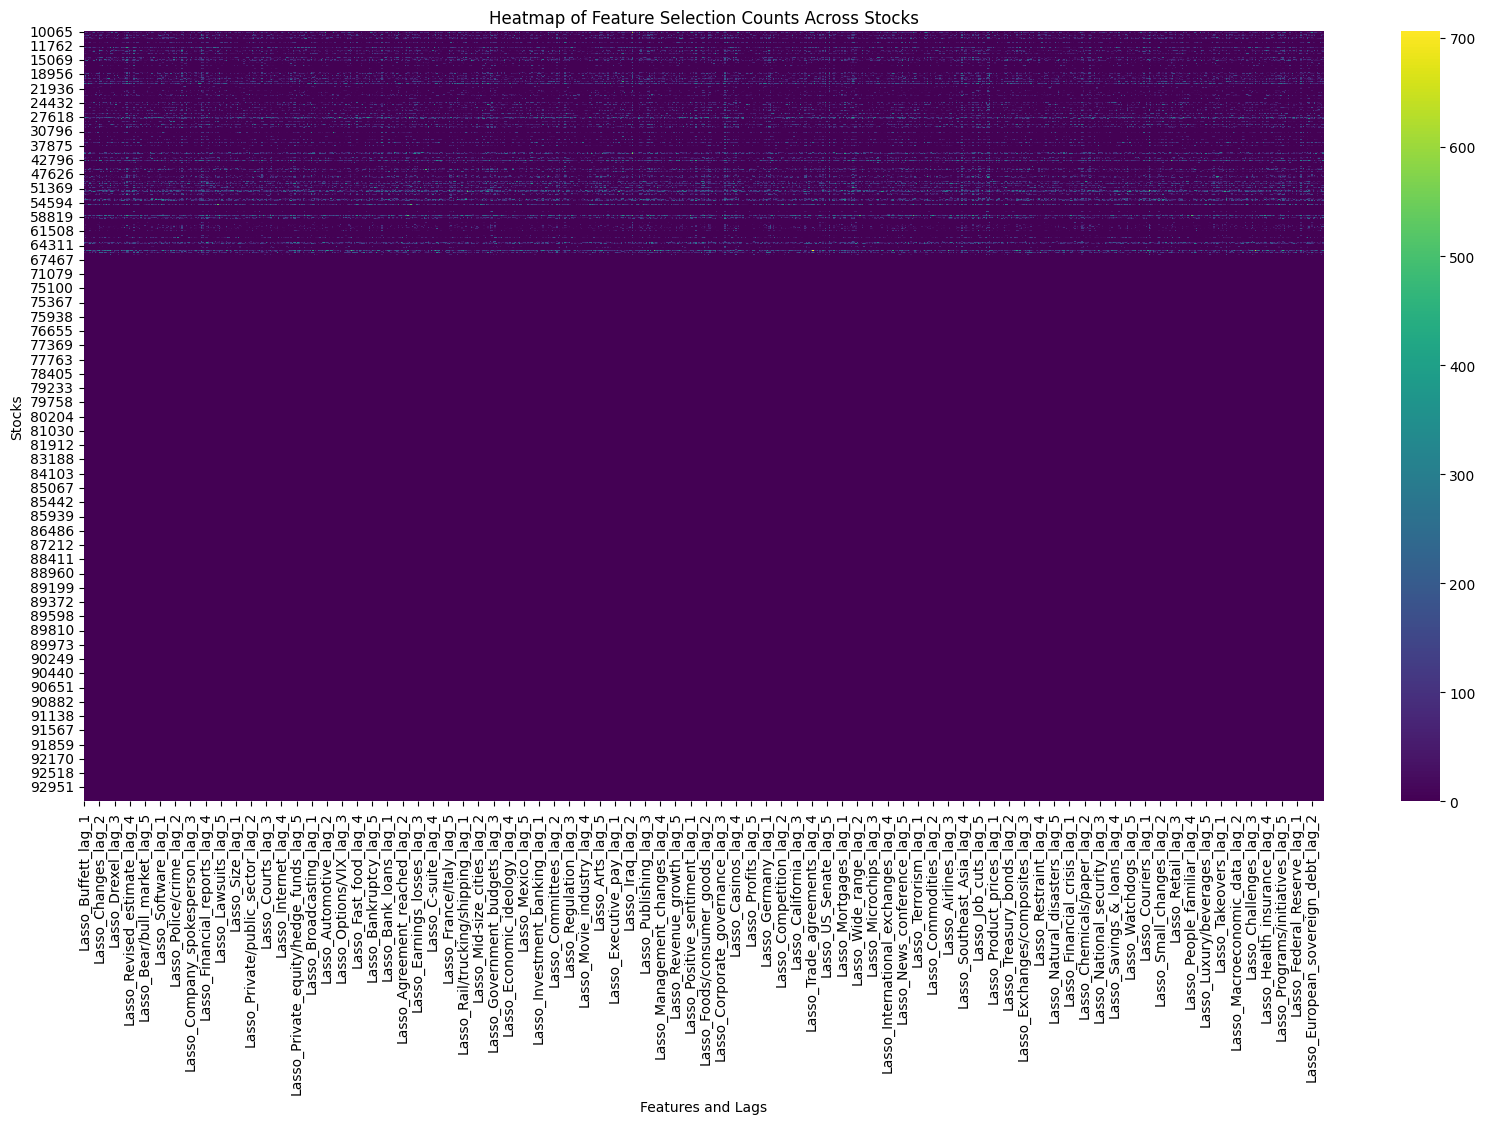

In [16]:
# seaborn heatmap of the results_df
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
sns.heatmap(results_df.drop(columns=['avg_num_selected_features']), cmap='viridis')
plt.title('Heatmap of Feature Selection Counts Across Stocks')
plt.xlabel('Features and Lags')
plt.ylabel('Stocks')
plt.show()